# Here we will train the residual model a.k.a model B

In [2]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, roc_auc_score
from scipy.stats import spearmanr
from lightgbm import LGBMRegressor      # pip install lightgbm

data = pd.read_parquet('../data/processed/tracks_enriched.parquet')
target = 'popularity'

# ---- split ONCE; both stages use the same test set so it's never touched in training
train, test = train_test_split(data, test_size=0.2, random_state=42)

In [3]:
# ===== STAGE 1: context model — expected popularity from EXTERNAL advantages only =====
from sklearn.model_selection import GridSearchCV
ctx_features = ['artist_fame_loo', 'track_genre']
tr, te = train.copy(), test.copy()
tr['track_genre'] = tr['track_genre'].astype('category')
te['track_genre'] = te['track_genre'].astype('category')



param_grid = [{'n_estimators': [100, 200, 300], 'learning_rate': list(np.arange(0.02, 0.13, 0.03))}]
gs = GridSearchCV(estimator=LGBMRegressor(), 
                  param_grid=param_grid, 
                  scoring='r2', 
                  cv=10, 
                  n_jobs=1)

gs.fit(tr[ctx_features], tr[target], categorical_feature=['track_genre'])

context = LGBMRegressor(**gs.best_params_, random_state=667)
context.fit(tr[ctx_features], tr[target], categorical_feature=['track_genre'])

# expected popularity, then residual = what fame+genre did NOT explain
train_resid = train[target].values - context.predict(tr[ctx_features])
test_resid  = test[target].values  - context.predict(te[ctx_features])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000386 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 80449, number of used features: 2
[LightGBM] [Info] Start training from score 33.770476
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000275 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 80449, number of used features: 2
[LightGBM] [Info] Start training from score 33.780122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000289 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 288
[LightGBM] [Info] Number of data points in the train set: 80449, number of used features: 2
[LightGBM] [Info] Start trainin

In [4]:
print(gs.best_score_)
print(gs.best_params_)

0.6343227689152523
{'learning_rate': np.float64(0.11000000000000001), 'n_estimators': 300}


In [5]:
# ===== STAGE 2: Model B — predict the residual from AUDIO only =====
audio = ['danceability','energy','key','loudness','mode','speechiness',
         'acousticness','instrumentalness','liveness','valence','tempo',
         'time_signature','duration_ms','explicit']

gs_b = GridSearchCV(estimator=LGBMRegressor(), 
                  param_grid=param_grid, 
                  scoring='r2', 
                  cv=10, 
                  n_jobs=1)

gs_b.fit(tr[ctx_features], tr[target], categorical_feature=['track_genre'])

model_b = LGBMRegressor(**gs_b.best_params_, random_state=667, importance_type='gain')
model_b.fit(train[audio], train_resid)

pred = model_b.predict(test[audio])
print("R²:      ", r2_score(test_resid, pred))
print("MAE:     ", mean_absolute_error(test_resid, pred))
print("Spearman:", spearmanr(test_resid, pred).correlation)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000309 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 80449, number of used features: 2
[LightGBM] [Info] Start training from score 33.770476
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000148 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 80449, number of used features: 2
[LightGBM] [Info] Start training from score 33.780122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 288
[LightGBM] [Info] Number of data points in the train set: 8

In [6]:
import numpy as np

def precision_at_k(y_true, y_pred, k=50, top_frac=0.10):
    # "actually good" = real residual in the top top_frac of the test set
    threshold = np.quantile(y_true, 1 - top_frac)
    top_k_idx = np.argsort(y_pred)[-k:]          # the model's K highest-scored songs
    hits = (np.asarray(y_true)[top_k_idx] >= threshold).sum()
    return hits / k

for k in (20, 50, 100, 200, 500, 1000, 10000, 100_000):
    print(f"Precision@{k}: {precision_at_k(test_resid, pred, k=k):.2%}")

Precision@20: 75.00%
Precision@50: 76.00%
Precision@100: 67.00%
Precision@200: 55.00%
Precision@500: 40.40%
Precision@1000: 31.10%
Precision@10000: 14.21%
Precision@100000: 2.23%


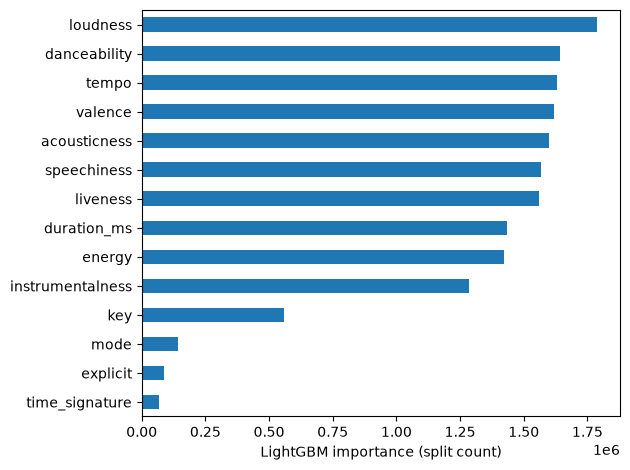

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.Series(model_b.feature_importances_, index=audio).sort_values()
imp.plot.barh()
plt.xlabel("LightGBM importance (split count)")
plt.tight_layout(); plt.show()

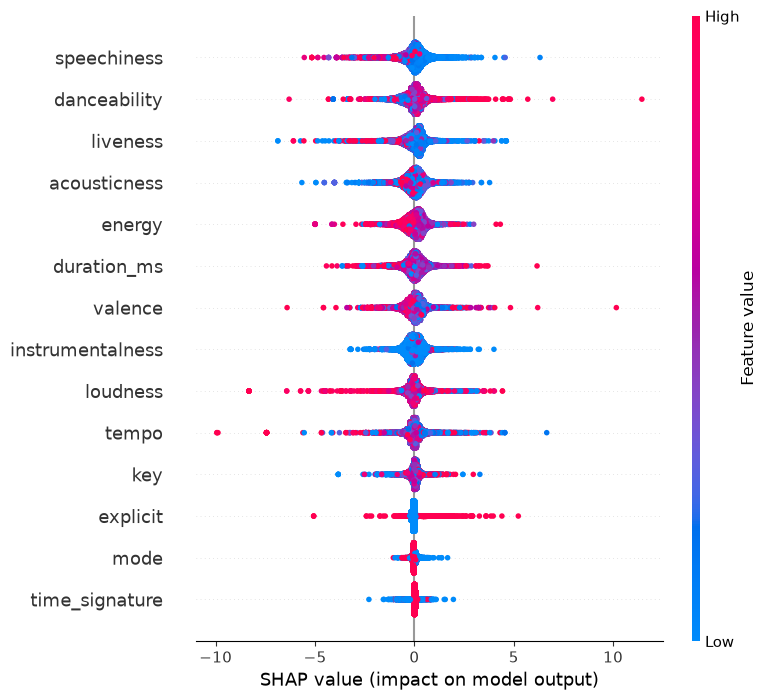

In [8]:
import shap
explainer = shap.TreeExplainer(model_b)
sv = explainer.shap_values(test[audio])
shap.summary_plot(sv, test[audio], feature_names=audio)

In [11]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

model_el = make_pipeline(
    StandardScaler(),                      # required — see below
    ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],  # mixes to try
        cv=5,
        n_jobs=-1,
    )
)
model_el.fit(train[audio], train_resid)

en = model_el.named_steps['elasticnetcv']
print('best alpha:', en.alpha_, 'best l1_ratio:', en.l1_ratio_)
print('nonzero coefs:', (en.coef_ != 0).sum(), 'of', len(en.coef_))

best alpha: 0.050414162396276344 best l1_ratio: 0.1
nonzero coefs: 14 of 14


In [12]:
pred_el = model_el.predict(test[audio])
print("R²:      ", r2_score(test_resid, pred_el))
print("MAE:     ", mean_absolute_error(test_resid, pred_el))
print("Spearman:", spearmanr(test_resid, pred_el).correlation)

R²:       0.0012130511430897828
MAE:      7.963543590878533
Spearman: 0.031199823520904453
